✅ Dataset Loaded. First 5 rows:
    iso  adm1  adm2 umd_global_land_cover__ipcc_class  \
0  RWA     1     3                          Cropland   
1  RWA     1     3                            Forest   
2  RWA     1     3                         Grassland   
3  RWA     1     3                             Other   
4  RWA     1     3                       Settlements   

   wri_tropical_tree_cover_extent__ha  
0                         3454.200913  
1                         6065.261714  
2                          950.569414  
3                            9.150596  
4                         7049.942587  

📊 Shape of dataset: (6, 5)

🧾 Columns:
 Index(['iso', 'adm1', 'adm2', 'umd_global_land_cover__ipcc_class',
       'wri_tropical_tree_cover_extent__ha'],
      dtype='object')

🔍 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                             

C:\Users\Elohome\AppData\Local\Temp\ipykernel_14748\3131913252.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


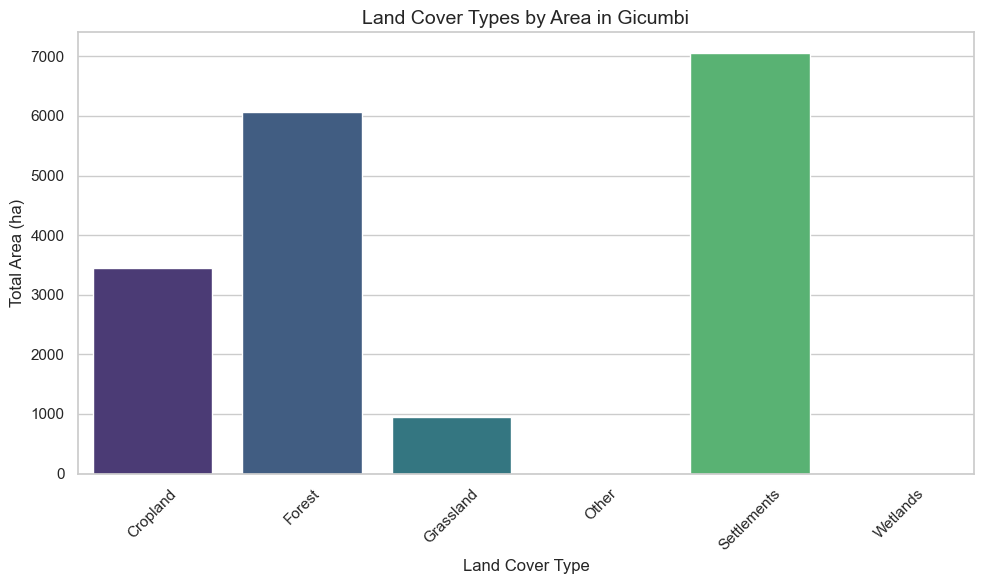

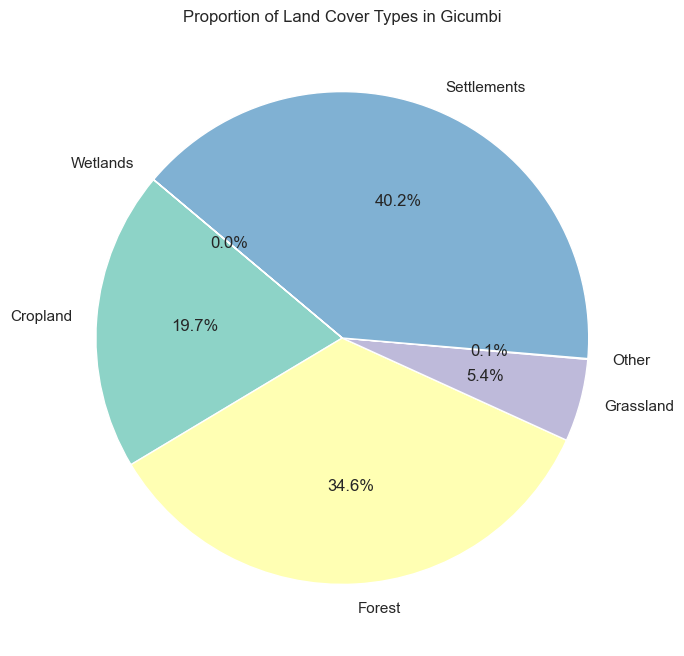

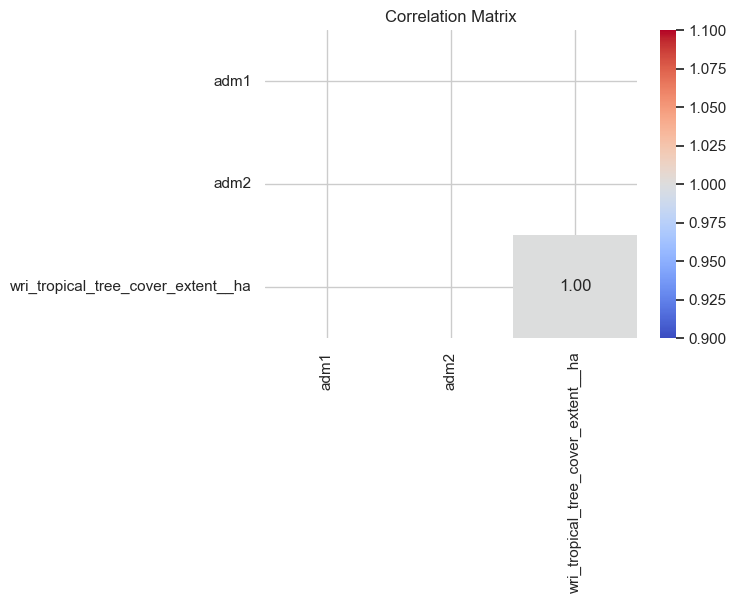

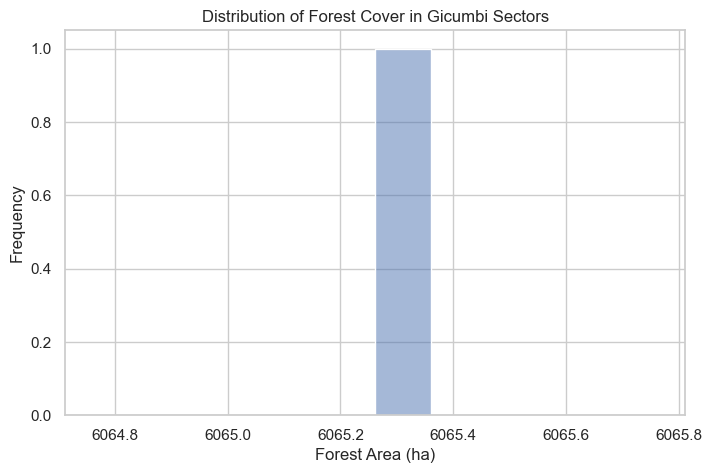


✅ Cleaned dataset saved as 'gicumbi_cleaned_for_modeling.csv'


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter settings
sns.set(style="whitegrid")
%matplotlib inline

# 2. Load Dataset
df = pd.read_csv("gicumbi_filtered_data.csv")  # Make sure the file name is correct
print("✅ Dataset Loaded. First 5 rows:\n", df.head())

# 3. Dataset Summary
print("\n📊 Shape of dataset:", df.shape)
print("\n🧾 Columns:\n", df.columns)
print("\n🔍 Info:")
df.info()

# 4. Check for Missing Values
print("\n❗ Missing values:\n", df.isnull().sum())

# 5. Descriptive Statistics
print("\n📈 Descriptive Statistics:\n", df.describe())

# 6. Distribution of Land Cover Types (Bar Plot)
plt.figure(figsize=(10,6))
sns.barplot(
    x="umd_global_land_cover__ipcc_class", 
    y="wri_tropical_tree_cover_extent__ha", 
    data=df, 
    estimator=sum,
    palette="viridis"
)
plt.title("Land Cover Types by Area in Gicumbi", fontsize=14)
plt.ylabel("Total Area (ha)")
plt.xlabel("Land Cover Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Pie Chart: Proportion of Land Cover in Gicumbi
land_cover = df.groupby("umd_global_land_cover__ipcc_class")["wri_tropical_tree_cover_extent__ha"].sum()

plt.figure(figsize=(8,8))
land_cover.plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3"))
plt.title("Proportion of Land Cover Types in Gicumbi")
plt.ylabel("")  # Hide y-label
plt.show()

# 8. Correlation Matrix
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# 9. Distribution Plot of Forest Cover Only
forest_df = df[df['umd_global_land_cover__ipcc_class'] == 'Forest']

plt.figure(figsize=(8,5))
sns.histplot(forest_df["wri_tropical_tree_cover_extent__ha"], bins=10, kde=True)
plt.title("Distribution of Forest Cover in Gicumbi Sectors")
plt.xlabel("Forest Area (ha)")
plt.ylabel("Frequency")
plt.show()

# 10. Save Cleaned Dataset (Optional)
df.to_csv("gicumbi_cleaned_for_modeling.csv", index=False)
print("\n✅ Cleaned dataset saved as 'gicumbi_cleaned_for_modeling.csv'")
